# Diabetes 130-US Hospitals (1999-2008) — Exploratory Data Analysis

General-overview EDA of the [Diabetes 130-US hospitals dataset](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008) (also mirrored on Kaggle). The dataset contains ~10 years of clinical care records for diabetic patients across 130 US hospitals, with the goal of studying hospital readmission.

**Files used**
- `diabetic_data.csv` — main encounter-level table (101,766 rows x 50 columns)
- `IDS_mapping.csv` — lookup tables that decode the numeric ID columns (`admission_type_id`, `discharge_disposition_id`, `admission_source_id`)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 60)


## 1. Load data

Works both on Kaggle (reading from `/kaggle/input/...`) and locally (reading from the sibling `diabetes+130-us+hospitals+for+years+1999-2008/` folder). If you add this dataset to a Kaggle notebook, update `kaggle_dir` to match the exact input folder name shown in the sidebar.

In [2]:
import os
import pandas as pd

diabetic_data_path = None
ids_mapping_path = None

# Dynamically search for the files
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename == 'diabetic_data.csv':
            diabetic_data_path = os.path.join(dirname, filename)
        elif filename == 'IDS_mapping.csv':
            ids_mapping_path = os.path.join(dirname, filename)

# Load if found, otherwise alert the user
if diabetic_data_path and ids_mapping_path:
    df = pd.read_csv(diabetic_data_path)
    ids_map = pd.read_csv(ids_mapping_path)
    
    print(f"Loaded successfully from: {os.path.dirname(diabetic_data_path)}")
    print("Diabetic data shape:", df.shape)
    print("IDS mapping shape:", ids_map.shape)
else:
    print("Error: Files not found.")
    print("Make sure you have clicked 'Add Data' in the right sidebar and attached the dataset to this session.")

Loaded successfully from: /kaggle/input/private-dataset
Diabetic data shape: (101766, 50)
IDS mapping shape: (67, 2)


## 2. First look

In [3]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [5]:
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0
patient_nbr,101766.0,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0
admission_type_id,101766.0,2.024006e+00,1.445403e+00,1.0,1.0,1.0,3.000000e+00,8.0
discharge_disposition_id,101766.0,3.715642e+00,5.280166e+00,1.0,1.0,1.0,4.000000e+00,28.0
admission_source_id,101766.0,5.754437e+00,4.064081e+00,1.0,1.0,7.0,7.000000e+00,25.0
time_in_hospital,101766.0,4.395987e+00,2.985108e+00,1.0,2.0,4.0,6.000000e+00,14.0
num_lab_procedures,101766.0,4.309564e+01,1.967436e+01,1.0,31.0,44.0,5.700000e+01,132.0
num_procedures,101766.0,1.339730e+00,1.705807e+00,0.0,0.0,1.0,2.000000e+00,6.0
num_medications,101766.0,1.602184e+01,8.127566e+00,1.0,10.0,15.0,2.000000e+01,81.0
number_outpatient,101766.0,3.693572e-01,1.267265e+00,0.0,0.0,0.0,0.000000e+00,42.0


## 3. Missing values

This dataset encodes missing values as the string `"?"` rather than `NaN`, so a plain `isna().sum()` will under-report missingness. We replace `"?"` with `NaN` first.

In [6]:
df_clean = df.replace("?", np.nan)

missing = df_clean.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_clean) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary


,missing_count,missing_pct
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


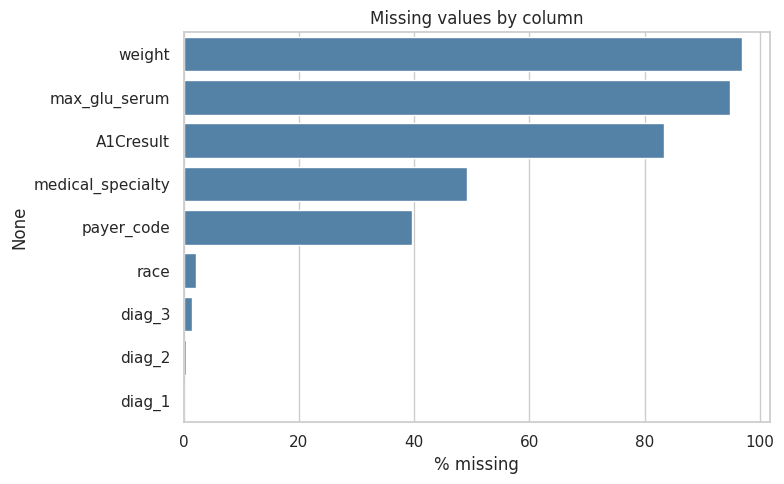

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=missing_summary["missing_pct"], y=missing_summary.index, ax=ax, color="steelblue")
ax.set_xlabel("% missing")
ax.set_title("Missing values by column")
plt.tight_layout()
plt.show()


## 4. Duplicates & patient-level structure

Each row is an *encounter* (hospital visit), not a unique patient — the same `patient_nbr` can appear multiple times. This matters for readmission analysis and for correct train/test splitting later.

In [8]:
print("Duplicate rows:", df.duplicated().sum())
print("Unique encounters:", df["encounter_id"].nunique())
print("Unique patients:", df["patient_nbr"].nunique())
print("Encounters per patient (top 5):")
df["patient_nbr"].value_counts().head()


Duplicate rows: 0
Unique encounters: 101766
Unique patients: 71518
Encounters per patient (top 5):


patient_nbr
88785891    40
43140906    28
88227540    23
1660293     23
23199021    23
Name: count, dtype: int64

## 5. Target variable: `readmitted`

/tmp/ipykernel_16/1815233395.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, order=order, palette="viridis", ax=ax)


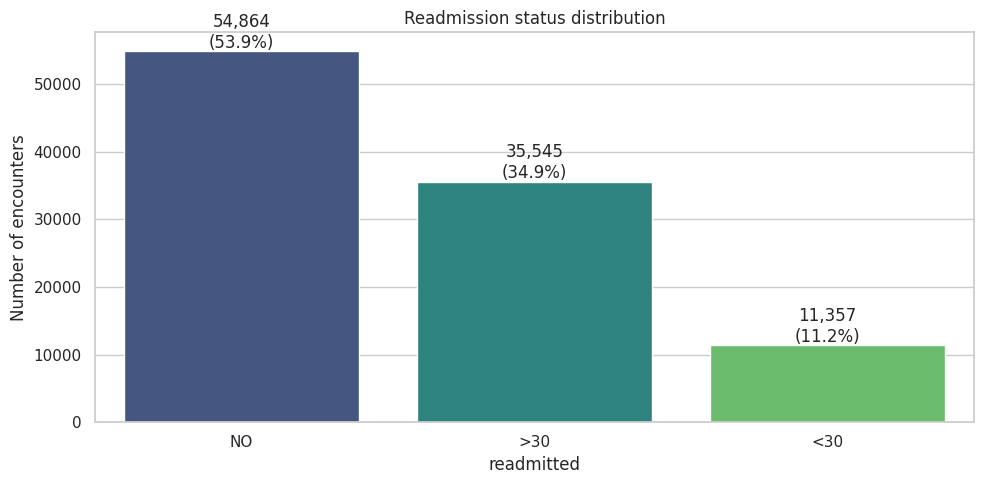

In [9]:
order = ["NO", ">30", "<30"]
counts = df["readmitted"].value_counts().reindex(order)

fig, ax = plt.subplots()
sns.barplot(x=counts.index, y=counts.values, order=order, palette="viridis", ax=ax)
ax.set_ylabel("Number of encounters")
ax.set_title("Readmission status distribution")
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center")
plt.tight_layout()
plt.show()


## 6. Numeric feature distributions

Core utilization/severity measures: length of stay, lab procedures, medications, prior visits.

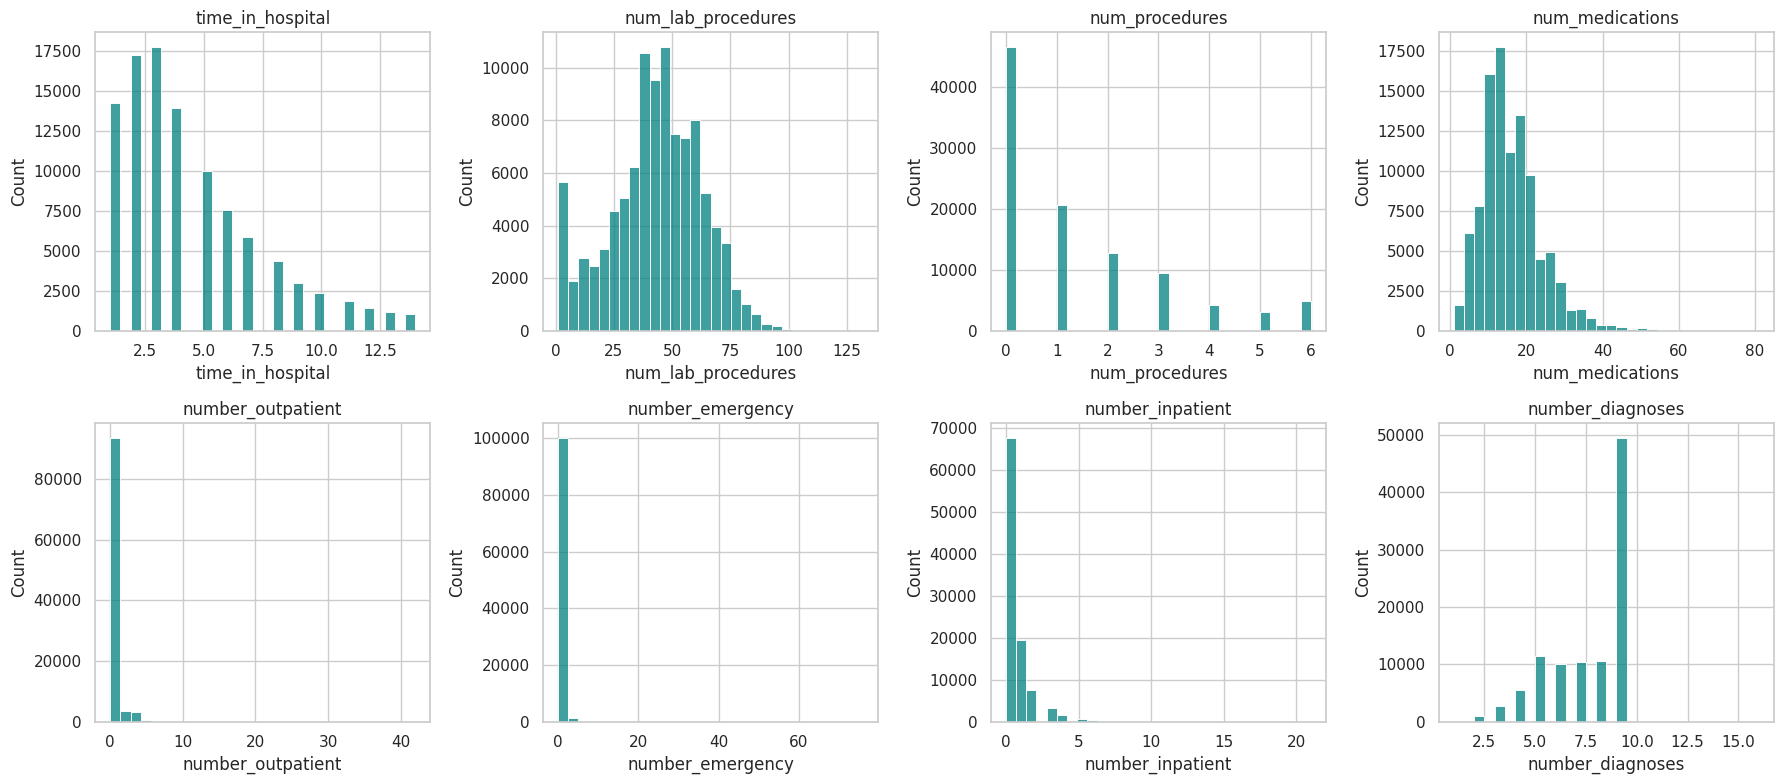

In [10]:
numeric_cols = [
    "time_in_hospital", "num_lab_procedures", "num_procedures",
    "num_medications", "number_outpatient", "number_emergency",
    "number_inpatient", "number_diagnoses",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for col, ax in zip(numeric_cols, axes.ravel()):
    sns.histplot(df[col], bins=30, ax=ax, color="teal")
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [11]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0
number_diagnoses,101766.0,7.422607,1.933600,1.0,6.0,8.0,9.0,16.0


## 7. Key categorical features

`age` is already binned into 10-year buckets; `race`, `gender`, `A1Cresult`, `max_glu_serum`, `change`, and `diabetesMed` are also of interest.

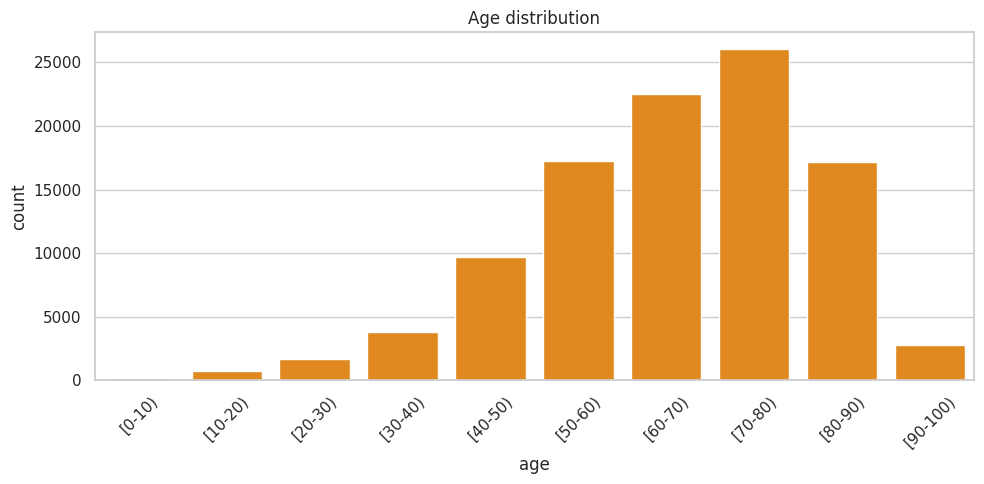

In [12]:
age_order = sorted(df["age"].unique(), key=lambda x: int(x.strip("[)").split("-")[0]))

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, x="age", order=age_order, color="darkorange", ax=ax)
ax.set_title("Age distribution")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


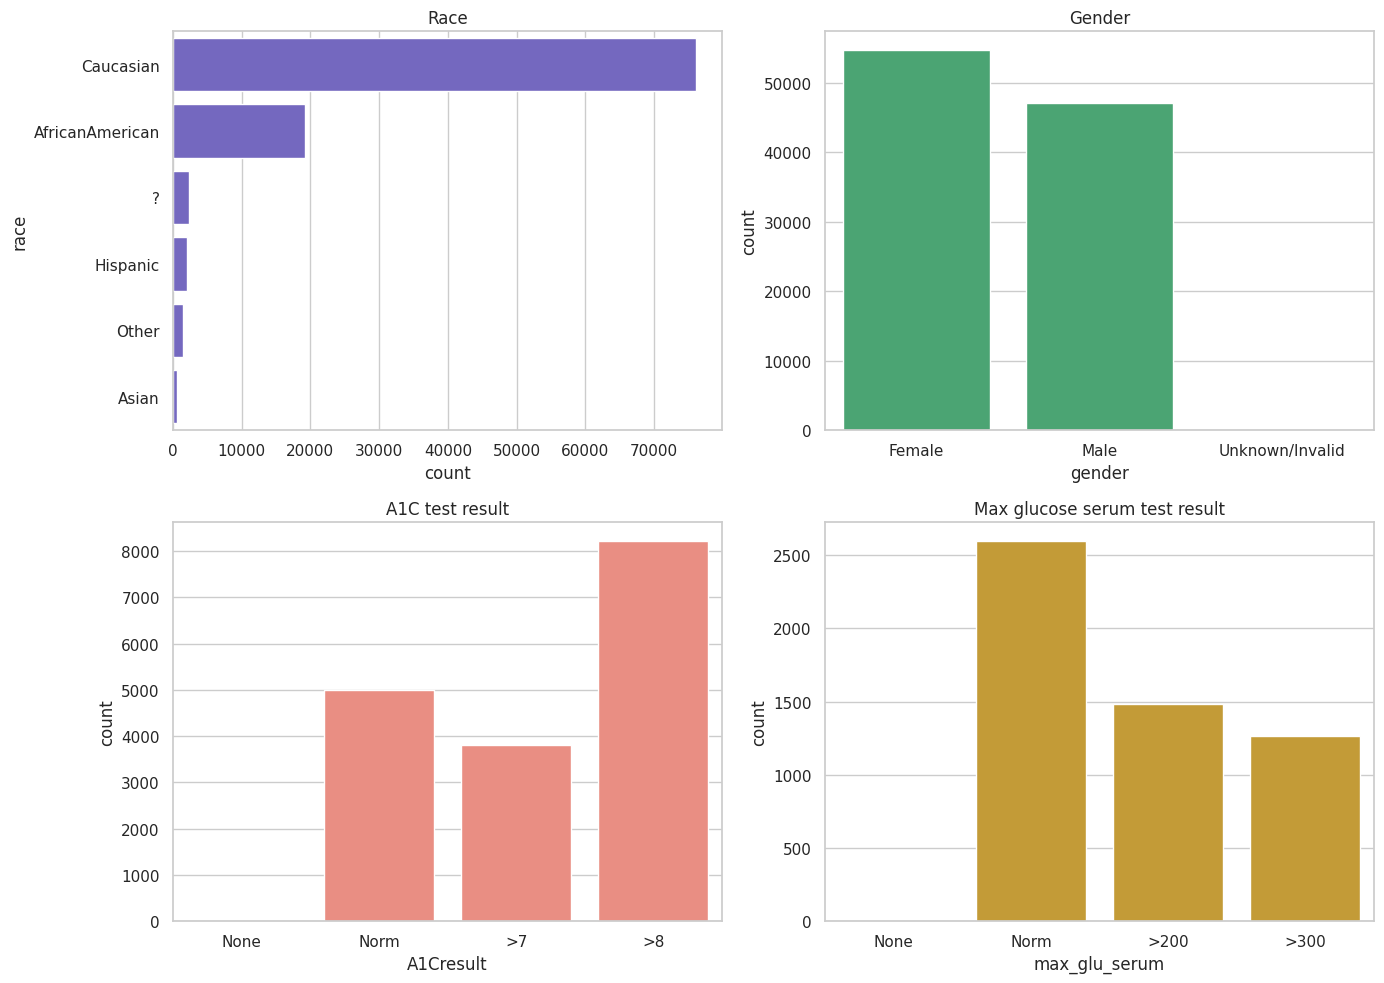

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, y="race", order=df["race"].value_counts().index, ax=axes[0, 0], color="slateblue")
axes[0, 0].set_title("Race")

sns.countplot(data=df, x="gender", ax=axes[0, 1], color="mediumseagreen")
axes[0, 1].set_title("Gender")

sns.countplot(data=df, x="A1Cresult", order=["None", "Norm", ">7", ">8"], ax=axes[1, 0], color="salmon")
axes[1, 0].set_title("A1C test result")

sns.countplot(data=df, x="max_glu_serum", order=["None", "Norm", ">200", ">300"], ax=axes[1, 1], color="goldenrod")
axes[1, 1].set_title("Max glucose serum test result")

plt.tight_layout()
plt.show()


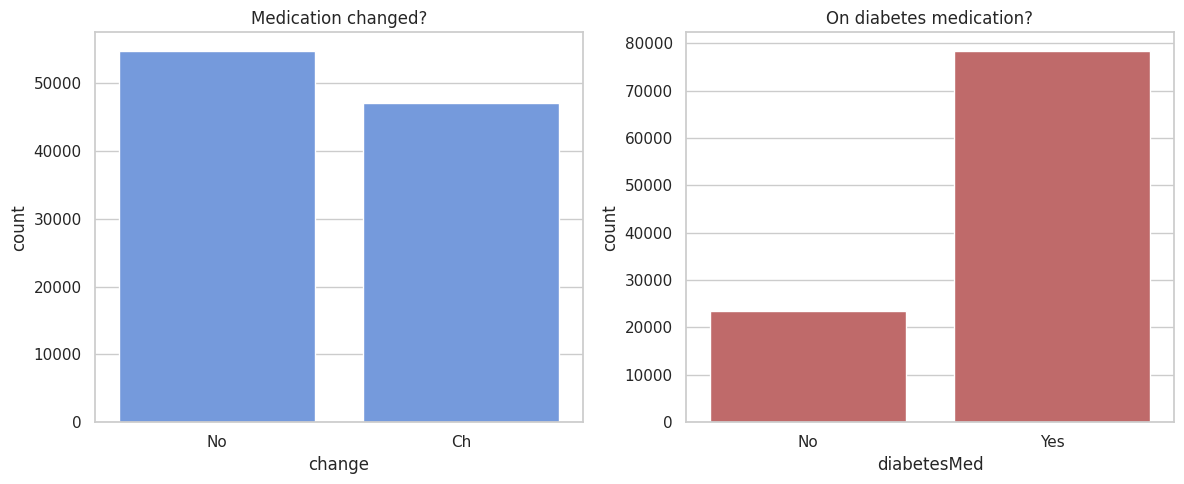

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x="change", ax=axes[0], color="cornflowerblue")
axes[0].set_title("Medication changed?")
sns.countplot(data=df, x="diabetesMed", ax=axes[1], color="indianred")
axes[1].set_title("On diabetes medication?")
plt.tight_layout()
plt.show()


## 8. Correlation between numeric features

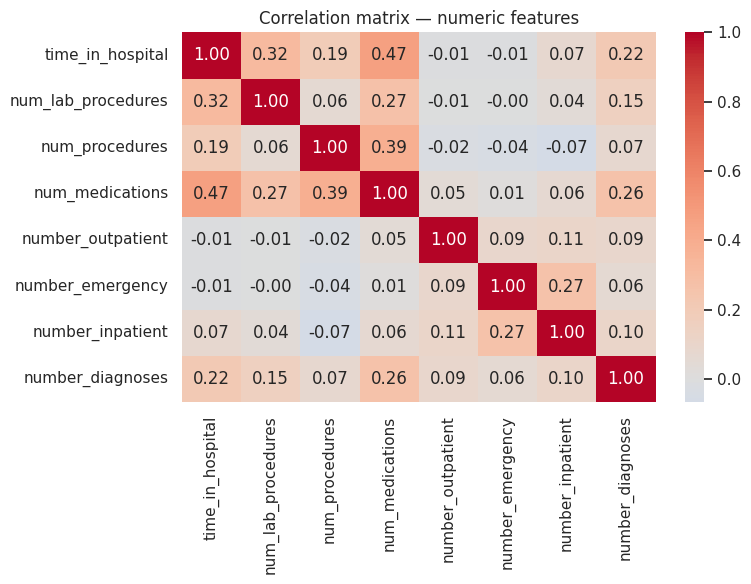

In [15]:
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix — numeric features")
plt.tight_layout()
plt.show()


## 9. Numeric features vs. readmission

Quick look at whether utilization measures differ by readmission status.

/tmp/ipykernel_16/85019454.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="readmitted", y=col, order=order, ax=ax, palette="Set2")
/tmp/ipykernel_16/85019454.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="readmitted", y=col, order=order, ax=ax, palette="Set2")
/tmp/ipykernel_16/85019454.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="readmitted", y=col, order=order, ax=ax, palette="Set2")
/tmp/ipykernel_16/85019454.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated 

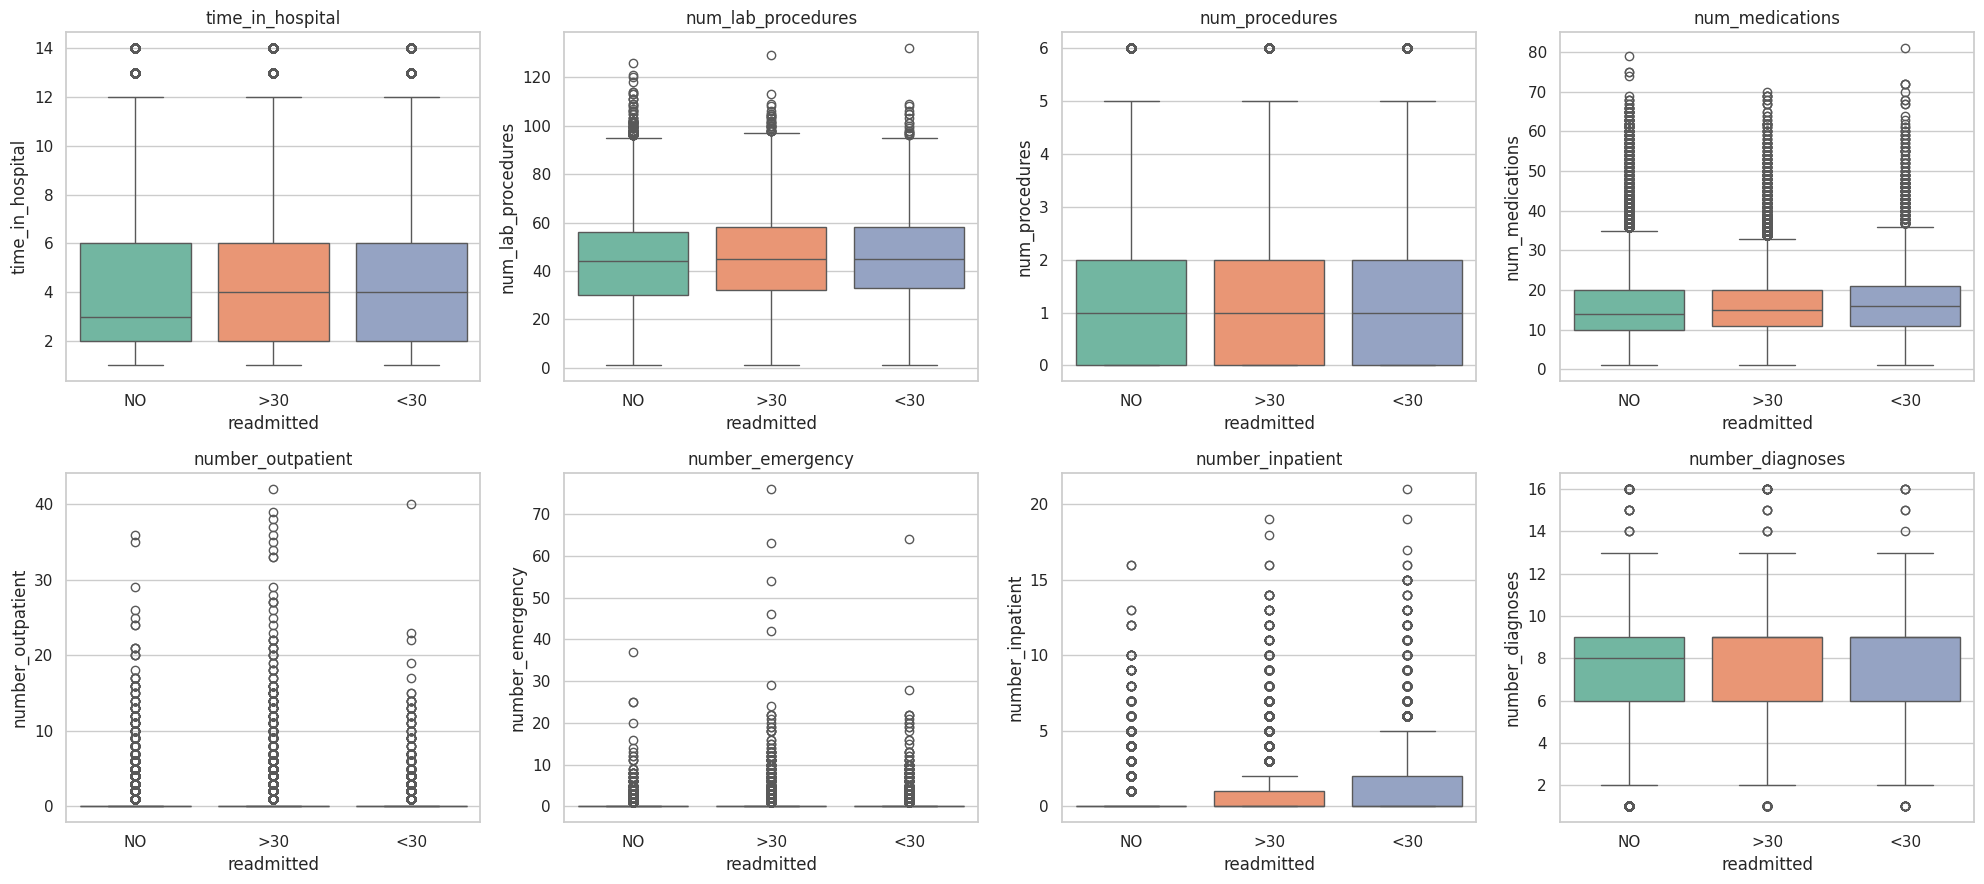

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for col, ax in zip(numeric_cols, axes.ravel()):
    sns.boxplot(data=df, x="readmitted", y=col, order=order, ax=ax, palette="Set2")
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 10. Age vs. readmission

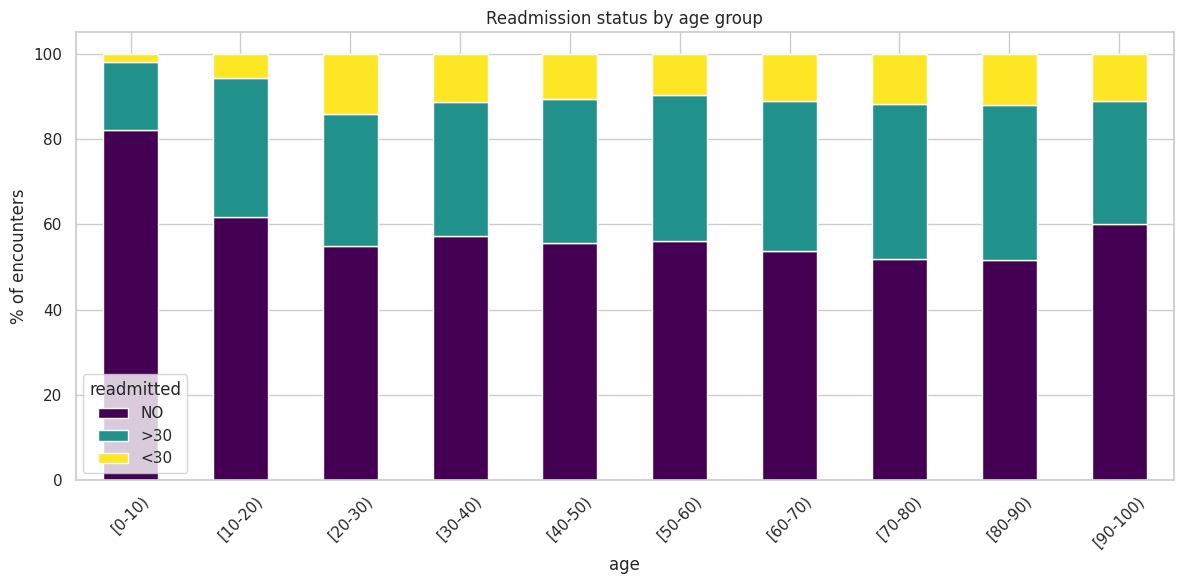

In [17]:
age_readmit = pd.crosstab(df["age"], df["readmitted"], normalize="index").reindex(age_order) * 100
age_readmit = age_readmit[order]

age_readmit.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="viridis")
plt.ylabel("% of encounters")
plt.title("Readmission status by age group")
plt.xticks(rotation=45)
plt.legend(title="readmitted")
plt.tight_layout()
plt.show()


## 11. Summary of initial findings

*(Fill in after reviewing the plots above — e.g. class balance of `readmitted`, which columns need imputation/dropping, notable skew in utilization features, any age/race patterns worth modeling.)*


In [18]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

# Automatically locate diabetic_data.csv in Kaggle input paths
data_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'diabetic_data.csv' in files:
        data_path = os.path.join(root, 'diabetic_data.csv')
        break

df = pd.read_csv(data_path if data_path else 'diabetic_data.csv')
df.replace('?', np.nan, inplace=True)
print(f"Initial raw shape: {df.shape}")

Initial raw shape: (101766, 50)


In [19]:
# 1. Exclude death/hospice discharges (cannot physically be readmitted)
expired_ids = [11, 13, 14, 19, 20, 21]
df = df[~df['discharge_disposition_id'].isin(expired_ids)].copy()

# 2. Drop high-missingness and non-predictive administrative IDs
df.drop(columns=['weight', 'payer_code', 'encounter_id'], inplace=True)

# 3. Create binary target: 1 if readmitted <30 days, 0 otherwise
df['target'] = (df['readmitted'] == '<30').astype(int)
df.drop(columns=['readmitted'], inplace=True)

# 4. Domain Feature Construction: Combine utilization into total_visits
df['total_visits'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']

print(f"Cleaned dataset shape: {df.shape}")
print("Class balance before split:\n", df['target'].value_counts(normalize=True))

Cleaned dataset shape: (99343, 48)
Class balance before split:
 target
0    0.886112
1    0.113888
Name: proportion, dtype: float64


In [20]:
# GroupShuffleSplit isolates patient_nbr to prevent data leakage between train/test splits
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['patient_nbr']))

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

# Separate features (X) and target (y), dropping patient identifier
X_train = train_df.drop(columns=['target', 'patient_nbr'])
y_train = train_df['target']

X_test = test_df.drop(columns=['target', 'patient_nbr'])
y_test = test_df['target']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (79541, 46)
X_test shape:  (19802, 46)


In [21]:
def map_icd9(code):
    if pd.isna(code):
        return 'Missing'
    code_str = str(code)
    if code_str.startswith('V') or code_str.startswith('E'):
        return 'Other'
    try:
        val = float(code_str)
        if 390 <= val <= 459 or val == 785:
            return 'Circulatory'
        elif 460 <= val <= 519 or val == 786:
            return 'Respiratory'
        elif 520 <= val <= 579 or val == 787:
            return 'Digestive'
        elif int(val) == 250:
            return 'Diabetes'
        elif 800 <= val <= 999:
            return 'Injury'
        elif 710 <= val <= 739:
            return 'Musculoskeletal'
        elif 580 <= val <= 629 or val == 788:
            return 'Genitourinary'
        elif 140 <= val <= 239:
            return 'Neoplasms'
        else:
            return 'Other'
    except ValueError:
        return 'Other'

# Apply ICD-9 grouping to train and test sets independently
for col in ['diag_1', 'diag_2', 'diag_3']:
    X_train[col] = X_train[col].apply(map_icd9)
    X_test[col] = X_test[col].apply(map_icd9)

In [22]:
# Format integer-coded categoricals to strings
coded_cats = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']
for c in coded_cats:
    X_train[c] = X_train[c].astype(str)
    X_test[c] = X_test[c].astype(str)

numeric_features = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'total_visits'
]

categorical_features = [c for c in X_train.columns if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# FIT ONLY ON TRAINING SET (Prevents Data Leakage)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
encoded_cat_names = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_cat_names)

X_train_clean = pd.DataFrame(X_train_processed, columns=all_feature_names)
X_test_clean = pd.DataFrame(X_test_processed, columns=all_feature_names)

print(f"Final Processed X_train shape: {X_train_clean.shape}")
print(f"Final Processed X_test shape:  {X_test_clean.shape}")

Final Processed X_train shape: (79541, 258)
Final Processed X_test shape:  (19802, 258)


In [23]:
# Balance class distribution strictly on training set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_clean, y_train)

print("Target distribution BEFORE SMOTE:\n", y_train.value_counts())
print("\nTarget distribution AFTER SMOTE:\n", y_train_smote.value_counts())

Target distribution BEFORE SMOTE:
 target
0    70443
1     9098
Name: count, dtype: int64

Target distribution AFTER SMOTE:
 target
0    70443
1    70443
Name: count, dtype: int64


In [24]:
# Save clean files directly into /kaggle/working/ for Member 3 modeling
X_train_clean.to_csv('X_train_processed.csv', index=False)
X_test_clean.to_csv('X_test_processed.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
X_train_smote.to_csv('X_train_smote.csv', index=False)
y_train_smote.to_csv('y_train_smote.csv', index=False)

print("Preprocessing phase complete! Dataframes ready in Kaggle memory and saved to output folder.")

Preprocessing phase complete! Dataframes ready in Kaggle memory and saved to output folder.


# 12. Logistic Regression Model Traning

In [25]:
# Load the OUTPUTS from  preprocessing pipeline (cells 29-35)
X_train_smote = pd.read_csv('X_train_smote.csv')
y_train_smote = pd.read_csv('y_train_smote.csv').squeeze()

X_test = pd.read_csv('X_test_processed.csv')
y_test = pd.read_csv('y_test.csv').squeeze()

print("✓ Data Loaded")
print(f"Training set (SMOTE): {X_train_smote.shape}")
print(f"Test set: {X_test.shape}")

✓ Data Loaded
Training set (SMOTE): (140886, 258)
Test set: (19802, 258)


**Scale Features**

Logistic regression uses gradient descent (distance-based). Without scaling, large-range features (time in hospital: 1-200 days) dominate small-range features (medications: 0-80), causing unfair weighting. StandardScaler converts all features to the same scale (mean ≈ 0, std ≈ 1). **Critical**: Fit scaler on training data only (`fit_transform`), then apply same transformation to test data (`transform`). This prevents data leakage.

In [26]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print("✅ Features Scaled")
print(f"Train mean: {X_train_scaled.mean():.4f} (target ≈ 0)")
print(f"Train std:  {X_train_scaled.std():.4f} (target ≈ 1)")

✅ Features Scaled
Train mean: 0.0000 (target ≈ 0)
Train std:  0.9942 (target ≈ 1)


**Model Traning**

In [27]:
#  ADD  IMPORTS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Now create and train model
model = LogisticRegression(
    max_iter=2000,
    random_state=42,
    solver='lbfgs',
    class_weight='balanced'
)

print("⏳ Training model...")
model.fit(X_train_scaled, y_train_smote)

print("✅ Model Trained!")
print(f"Intercept: {model.intercept_[0]:.4f}")
print(f"Coefficient shape: {model.coef_.shape}")

⏳ Training model...
✅ Model Trained!
Intercept: 0.0048
Coefficient shape: (1, 258)


**Make Predictions on Test Data**

Generate two prediction types: `y_pred` (class prediction: 0 or 1) and `y_pred_proba` (probability: [P(no readmit), P(readmit <30d)]). Class predictions are simple yes/no decisions. Probability predictions enable flexible thresholding  flag only high-risk patients (P > 0.7) instead of hard 50% cutoff. Both are needed: classes for clarity, probabilities for operational flexibility.

In [28]:
# Predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

print("✅ Predictions Generated")
print(f"\nFirst 10 predictions: {y_pred[:10]}")
print(f"\nFirst 5 probabilities:\n")
print(y_pred_proba[:5])
print(f"\n(Left column = P(No Readmit), Right = P(Readmit <30d))")

✅ Predictions Generated

First 10 predictions: [0 0 0 0 0 0 0 1 1 0]

First 5 probabilities:

[[0.54281662 0.45718338]
 [0.54279811 0.45720189]
 [0.69043273 0.30956727]
 [0.65803657 0.34196343]
 [0.77416373 0.22583627]]

(Left column = P(No Readmit), Right = P(Readmit <30d))


**Save Model & Results**

In [29]:
# STEP 4: Extract Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'Coefficient': model.coef_[0],
    'Abs_Coefficient': np.abs(model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("✅ Feature Importance Created")
print(feature_importance.head(10))

✅ Feature Importance Created
                          Feature  Coefficient  Abs_Coefficient
6                number_inpatient     0.338253         0.338253
44    discharge_disposition_id_22     0.196860         0.196860
87   medical_specialty_Gynecology    -0.162728         0.162728
8                    total_visits     0.150280         0.150280
128    medical_specialty_Resident     0.143807         0.143807
4               number_outpatient    -0.115300         0.115300
34            admission_type_id_7    -0.104432         0.104432
7                number_diagnoses     0.099934         0.099934
36     discharge_disposition_id_1    -0.091963         0.091963
106   medical_specialty_Pathology    -0.090378         0.090378


In [30]:
import joblib

# Save model & scaler
joblib.dump(model, 'logistic_regression_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')

# Save predictions
results = pd.DataFrame({
    'y_actual': y_test.values,
    'y_pred': y_pred,
    'y_prob_no_readmit': y_pred_proba[:, 0],
    'y_prob_readmit': y_pred_proba[:, 1]
})
results.to_csv('logistic_regression_predictions.csv', index=False)

# Save feature importance
feature_importance.to_csv('feature_importance.csv', index=False)

print("✅ Saved:")
print("  • logistic_regression_model.pkl")
print("  • feature_scaler.pkl")
print("  • logistic_regression_predictions.csv")
print("  • feature_importance.csv")

✅ Saved:
  • logistic_regression_model.pkl
  • feature_scaler.pkl
  • logistic_regression_predictions.csv
  • feature_importance.csv
